# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

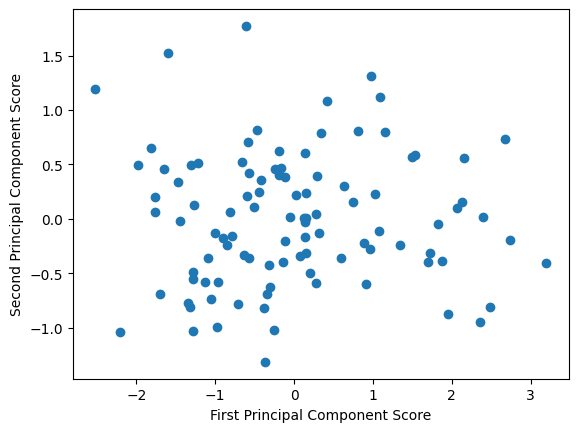

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The outliers in the upper left corner have a lower first principal component score and a higher second principal component score. I would expect Series 3 to have much higher values than in Series 1 or Series 2. It is much more difficult to say anything about the relative values of Series 1 and Series 2 than with Series 3 and one of the other series because Series 1 and Series 2 because they don't vary much between one another. Series 1 and 2 are near linear multiples of one another, so PCA basically treats them as redundant.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

**Datasets**

In [2]:
# Credit Card Fraud Detection Dataset
df_fraud = pd.read_csv("Fraud_Detection_Data_Train_sampled.csv")

In [28]:
df_fraud.columns

Index(['id', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [3]:
# Credit Card Approval Prediction Dataset
df_credit = pd.read_csv("Credit_Card_Application_Data.csv")

In [4]:
# Loan Default Prediction Dataset
df_loan = pd.read_csv("Loan_Default_Data_Train.csv")

**Heatmaps**

*Credit Card Fraud Detection Dataset*

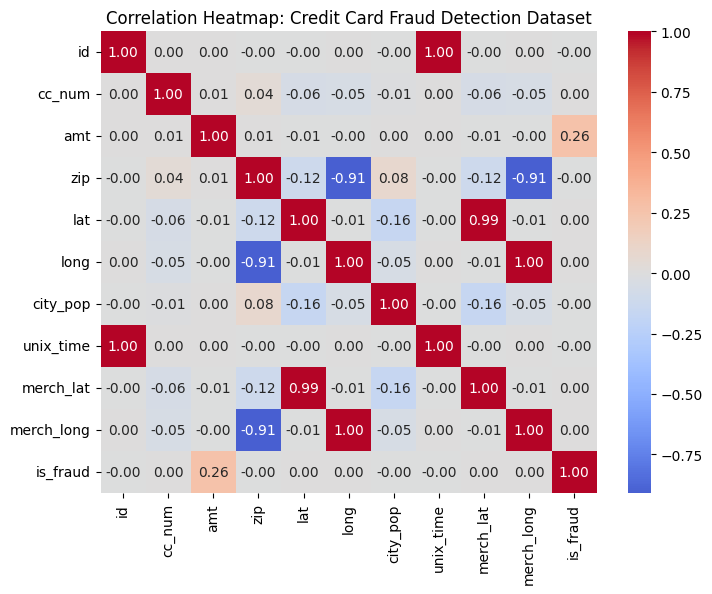

In [9]:
plt.figure(figsize=(8, 6))
numeric_cols = df_fraud.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df_fraud[numeric_cols].corr(), fmt=".2f", annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: Credit Card Fraud Detection Dataset")
plt.show()

*Credit Card Approval Prediction Dataset*

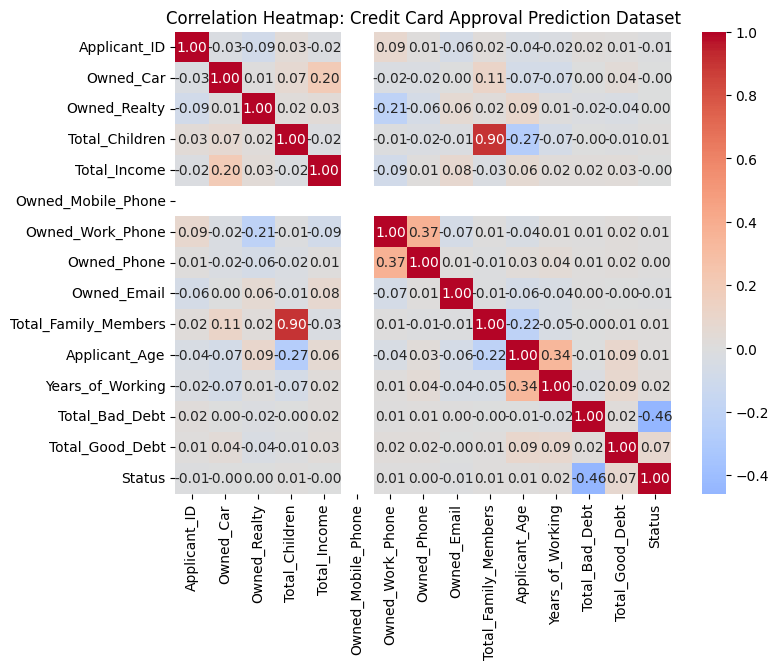

In [10]:
plt.figure(figsize=(8, 6))
numeric_cols2 = df_credit.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df_credit[numeric_cols2].corr(), fmt=".2f", annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: Credit Card Approval Prediction Dataset")
plt.show()

*Loan Default Prediction Dataset*

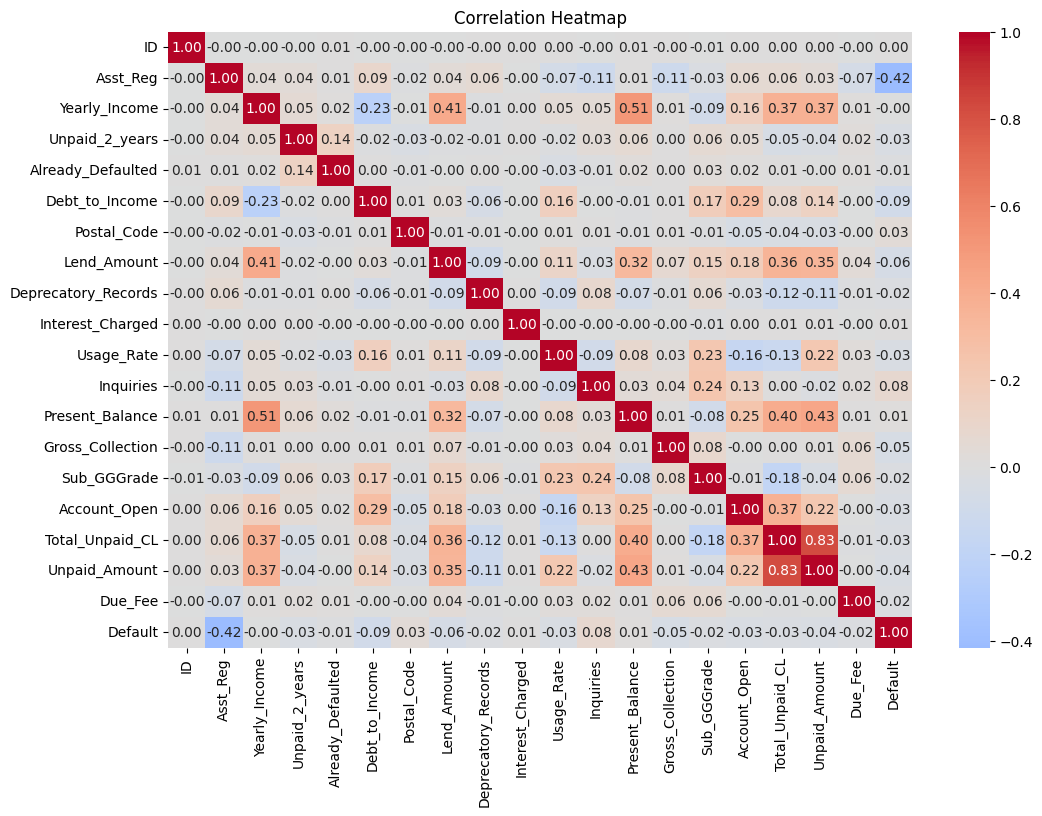

In [8]:
plt.figure(figsize=(12, 8))
numeric_cols3 = df_loan.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df_loan[numeric_cols3].corr(), fmt=".2f", annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

**Bubble Plots**

*Credit Card Fraud Detection Dataset*

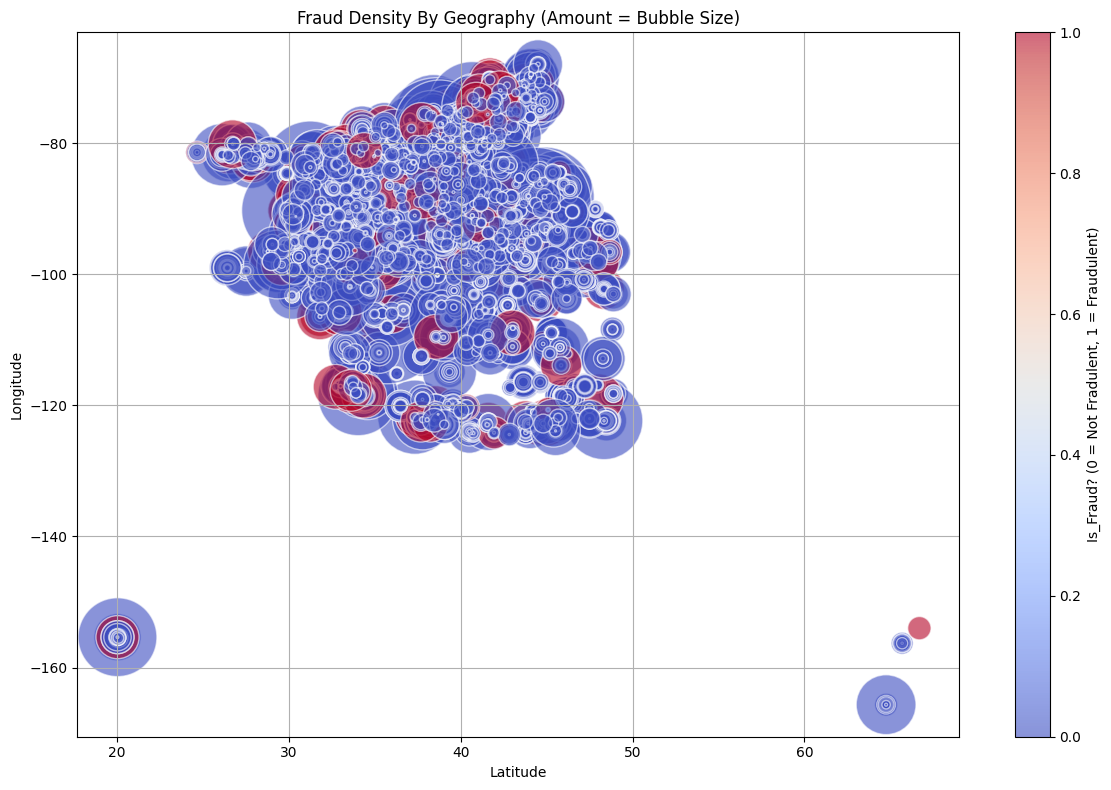

In [38]:
# Trying to show fraud density by geographical coordinates and identify outliers
plt.figure(figsize=(12, 8))
bubble = plt.scatter(
    df_fraud['lat'], 
    df_fraud['long'], 
    s=df_fraud['amt'],
    c=df_fraud["is_fraud"],
    cmap='coolwarm',
    alpha=0.6, 
    edgecolors='w'
)

# Labels and titles
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Fraud Density By Geography (Amount = Bubble Size)")
plt.grid(True)
plt.colorbar(label="Is_Fraud? (0 = Not Fradulent, 1 = Fraudulent)")
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show()

*Credit Card Approval Prediction Dataset*

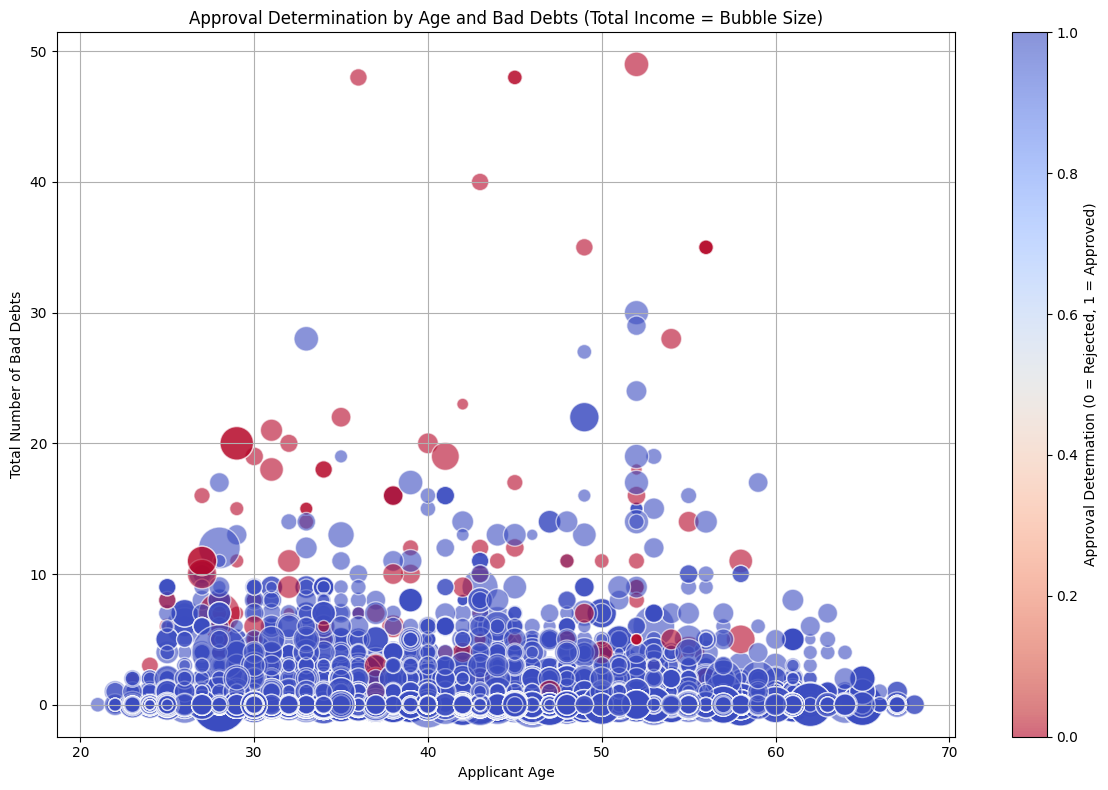

In [53]:
# Trying to show approval decisions based on applicant age, total number of bad debts, and total income
plt.figure(figsize=(12, 8))
bubble = plt.scatter(
    df_credit['Applicant_Age'], 
    df_credit['Total_Bad_Debt'], 
    s=df_credit['Total_Income'] / 1000,
    c=df_credit["Status"],
    cmap='coolwarm_r',
    alpha=0.6, 
    edgecolors='w'
)

# Labels and titles
plt.xlabel("Applicant Age")
plt.ylabel("Total Number of Bad Debts")
plt.title("Approval Determination by Age and Bad Debts (Total Income = Bubble Size)")
plt.grid(True)
plt.colorbar(label="Approval Determation (0 = Rejected, 1 = Approved)")
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show()

*Loan Default Prediction Dataset*

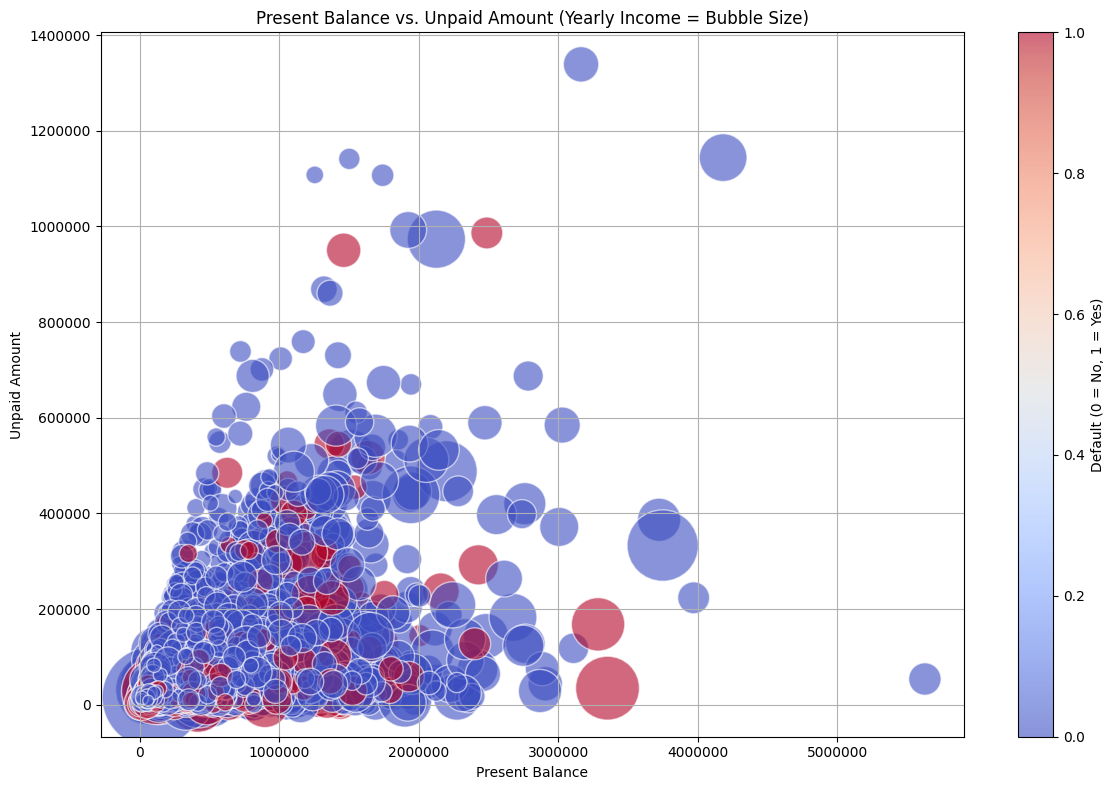

In [55]:
# Trying to show the distribution of loan defaults based on the present balance and unpaid amount
plt.figure(figsize=(12, 8))
bubble = plt.scatter(
    df_loan['Present_Balance'], 
    df_loan['Unpaid_Amount'], 
    s=df_loan['Yearly_Income'] / 1000,  # Scaling
    c=df_loan["Default"],
    cmap='coolwarm',
    alpha=0.6, 
    edgecolors='w'
)

# Labels and titles
plt.xlabel("Present Balance")
plt.ylabel("Unpaid Amount")
plt.title("Present Balance vs. Unpaid Amount (Yearly Income = Bubble Size)")
plt.grid(True)
plt.colorbar(label="Default (0 = No, 1 = Yes)")
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show()

**Principal Component Analysis**

In [56]:
from sklearn.decomposition import PCA

In [58]:
pd.set_option('display.float_format', '{:.10f}'.format) 

*Credit Card Fraud Detection Dataset*

In [57]:
df_fraud_numeric = df_fraud.select_dtypes(include='number')

In [62]:
pca_fraud = PCA(n_components=3)

pca_fraud.fit(df_fraud_numeric)

components = pd.DataFrame(pca_fraud.components_, columns=df_fraud_numeric.columns, index=['PC1', 'PC2', 'PC3'])
print("PCA Components:")
print(components)

PCA Components:
               id        cc_num          amt           zip           lat  \
PC1  0.0000000000  1.0000000000 0.0000000000  0.0000000000 -0.0000000000   
PC2  0.0000255606 -0.0000000000 0.0000000503 -0.0000024231 -0.0000000006   
PC3 -0.0000000000  0.0000000000 0.0000017303  0.0068433284 -0.0000026222   

             long      city_pop    unix_time     merch_lat    merch_long  \
PC1 -0.0000000000 -0.0000000000 0.0000000000 -0.0000000000 -0.0000000000   
PC2  0.0000000024 -0.0000149911 0.9999999996 -0.0000000007  0.0000000023   
PC3 -0.0000022115  0.9999765840 0.0000150073 -0.0000026303 -0.0000022095   

         is_fraud  
PC1  0.0000000000  
PC2 -0.0000000000  
PC3 -0.0000000005  


This dataset did not have any features/variables that were strong enough to be considered a strong proxy for any of the principal components.

*Credit Card Approval Prediction Dataset*

In [60]:
df_credit_numeric = df_credit.select_dtypes(include='number')

In [63]:
pca_credit = PCA(n_components=3)

pca_credit.fit(df_credit_numeric)

components = pd.DataFrame(pca_credit.components_, columns=df_credit_numeric.columns, index=['PC1', 'PC2', 'PC3'])
print("PCA Components:")
print(components)

PCA Components:
     Applicant_ID     Owned_Car  Owned_Realty  Total_Children  Total_Income  \
PC1 -0.0091997331  0.0000009328  0.0000001584   -0.0000001117  0.9999576815   
PC2  0.9999576815 -0.0000002423 -0.0000009682    0.0000005785  0.0091997332   
PC3 -0.0000031287  0.0007220388 -0.0009511769   -0.0016215389 -0.0000048653   

     Owned_Mobile_Phone  Owned_Work_Phone  Owned_Phone   Owned_Email  \
PC1        0.0000000000     -0.0000003865 0.0000000472  0.0000002195   
PC2       -0.0000000000      0.0000009063 0.0000001452 -0.0000004387   
PC3        0.0000000000      0.0007396183 0.0006421121 -0.0001493257   

     Total_Family_Members  Applicant_Age  Years_of_Working  Total_Bad_Debt  \
PC1         -0.0000002319   0.0000053065      0.0000012154    0.0000002268   
PC2          0.0000005244  -0.0000081867     -0.0000033218    0.0000008000   
PC3         -0.0001407029   0.1070153426      0.0578877768    0.0024103175   

     Total_Good_Debt        Status  
PC1     0.0000042285 -0.0000

Total_Income is a strong proxy for PC1. Applicant_ID is a strong proxy for PC2. Total_Good_Debt is a strong proxy for PC3.

*Loan Default Prediction Dataset*

In [64]:
df_loan_numeric = df_loan.select_dtypes(include='number')

In [65]:
pca_loan = PCA(n_components=3)

pca_loan.fit(df_loan_numeric)

components = pd.DataFrame(pca_loan.components_, columns=df_loan_numeric.columns, index=['PC1', 'PC2', 'PC3'])
print("PCA Components:")
print(components)

PCA Components:
               ID      Asst_Reg  Yearly_Income  Unpaid_2_years  \
PC1 -0.0000667603  0.9999970059   0.0014708103    0.0000000140   
PC2  0.0007103375 -0.0016042192   0.1986609063    0.0000002081   
PC3 -0.0035405926 -0.0015052269   0.9427248402    0.0000000181   

     Already_Defaulted  Debt_to_Income   Postal_Code  Lend_Amount  \
PC1       0.0000000003    0.0000005473 -0.0002115567 0.0002369807   
PC2       0.0000000059   -0.0000012769 -0.0013888433 0.0191599481   
PC3       0.0000000045   -0.0000405248 -0.0022986428 0.0550122958   

     Deprecatory_Records  Interest_Charged    Usage_Rate     Inquiries  \
PC1         0.0000000159     -0.0000000064 -0.0000013177 -0.0000000461   
PC2        -0.0000001653     -0.0000000202  0.0000123444  0.0000001402   
PC3         0.0000001335      0.0000002813 -0.0000024321  0.0000003833   

     Present_Balance  Gross_Collection   Sub_GGGrade  Account_Open  \
PC1     0.0011749924     -0.0000184193 -0.0000000714  0.0000001309   
PC2  

Asst_Reg is a strong proxy for PC1. Present_Balance is a strong proxy for PC2. Yearly_Income is a strong proxy for PC3.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

In [66]:
df_credit = pd.read_csv("Credit_Card_Application_Data.csv")

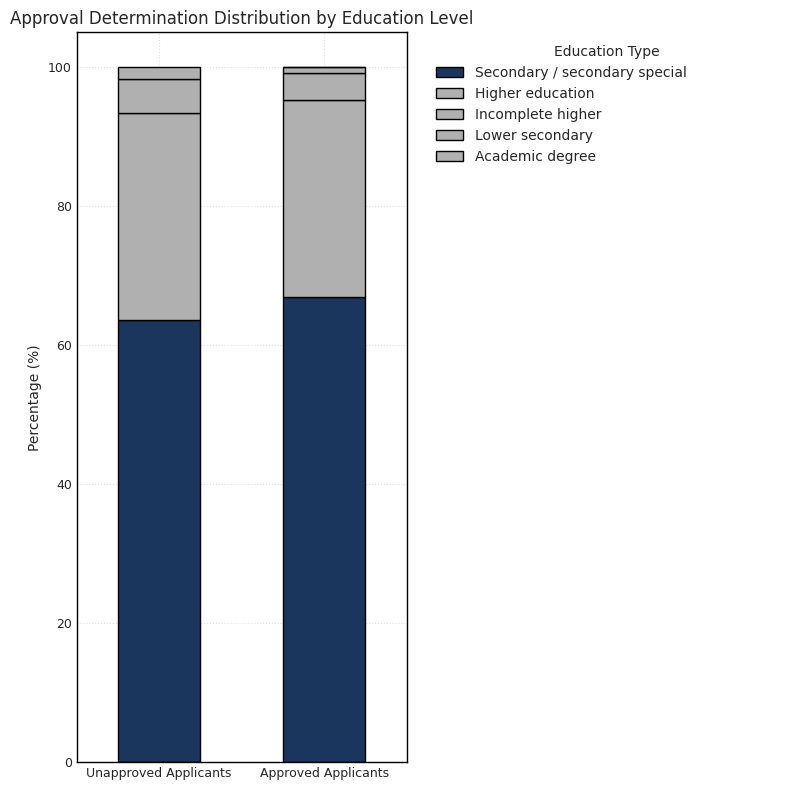

In [73]:
# Calculate the unapproved and approved population by education type
unapproved_edu = df_credit[df_credit['Status'] == 0]['Education_Type'].value_counts(normalize=True) * 100
approved_edu = df_credit[df_credit['Status'] == 1]['Education_Type'].value_counts(normalize=True) * 100

# Creating dataframe with value counts
edu_dist = pd.DataFrame({
    'Unapproved Applicants': unapproved_edu,
    'Approved Applicants': approved_edu
}).fillna(0).sort_values(by='Approved Applicants', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))

# Styling
plt.style.use('seaborn-v0_8-whitegrid')

# Assumption: the most education type will differ between unapproved and approved applicants
# Color logic: highlight most common education type
highlight_color = '#1B365D'
neutral_color = '#B0B0B0'
num_highlight = 1
colors = [highlight_color if i < num_highlight else neutral_color for i in range(len(edu_dist))]

# Transpose for stacked vertical bars
bars = edu_dist.T.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',
    linewidth=1
)

# Labels and chart characteristics
ax.set_ylabel("Percentage (%)")
ax.set_title("Approval Determination Distribution by Education Level")
plt.xticks(rotation=0)
plt.legend(title="Education Type", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', linestyle=':', alpha=0.6)
ax.tick_params(axis='both', which='major', labelsize=9)

# Add black outline to the graph
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# Layout / plot
plt.tight_layout()
plt.show()

This chart is based on Figure 5.13 on page 143.